**Name - Arihant Gupta**
<br>
**Enrolment - E23CSEU0055**
<br>
**Batch - EB_02**
<br>
**Date - 06 Nov 2025**
<br>
**Lab - 20**
<br>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.stats import mode

In [14]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X = np.concatenate((X_train, X_test), axis=0)
y_true = np.concatenate((y_train, y_test), axis=0)

n_samples = X.shape[0]
n_features = 784
X_flat = X.reshape(n_samples, n_features).astype('float32')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

print(f"Original Data Shape (Flattened and Scaled): {X_scaled.shape}")

Original Data Shape (Flattened and Scaled): (70000, 784)


In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA Reduced Data Shape: {X_pca.shape}")
print(f"Explained Variance Ratio (First 2 Components): {np.sum(pca.explained_variance_ratio_):.4f}")

PCA Reduced Data Shape: (70000, 2)
Explained Variance Ratio (First 2 Components): 0.0968


In [16]:
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_pca)
y_pred_cluster = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

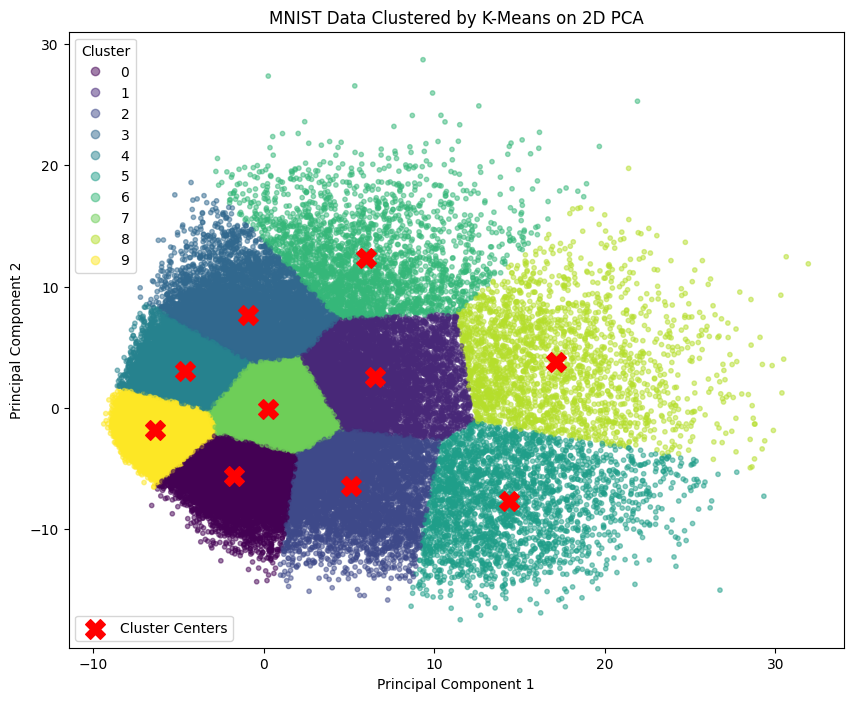

In [17]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_cluster, cmap='viridis', s=10, alpha=0.5)

plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', marker='X', s=200, label='Cluster Centers')

plt.title('MNIST Data Clustered by K-Means on 2D PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)
plt.legend(loc='lower left')
plt.show()

**Accuracy Score (after mapping): 0.3330**


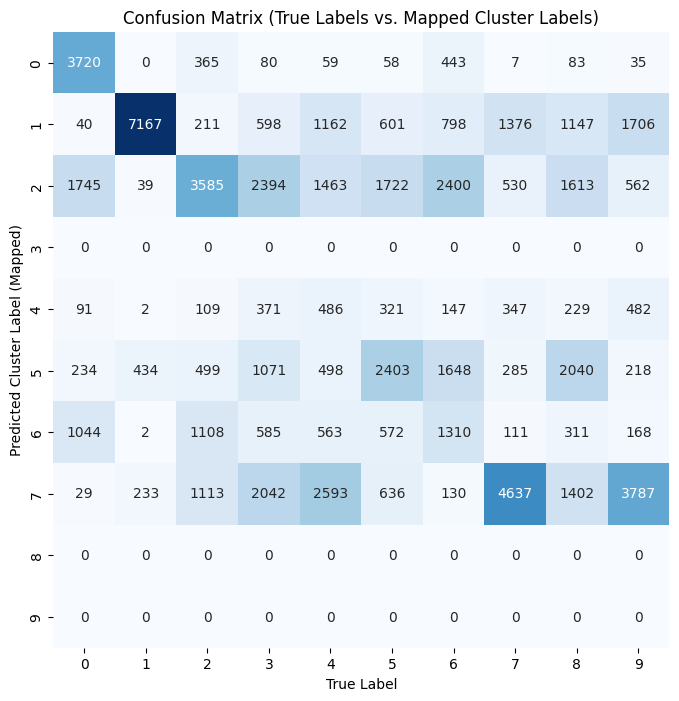

In [18]:
labels = np.zeros_like(y_pred_cluster)
for i in range(n_clusters):
    mask = (y_pred_cluster == i)
    most_frequent_label = mode(y_true[mask])[0]
    labels[mask] = most_frequent_label

accuracy = accuracy_score(y_true, labels)
print(f"**Accuracy Score (after mapping): {accuracy:.4f}**")

conf_mat = confusion_matrix(y_true, labels)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10), cmap='Blues')
plt.xlabel('True Label')
plt.ylabel('Predicted Cluster Label (Mapped)')
plt.title('Confusion Matrix (True Labels vs. Mapped Cluster Labels)')
plt.show()